In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import odc.stac
import planetary_computer
from distributed import LocalCluster
from IPython.display import Image
from matplotlib.colors import BoundaryNorm, ListedColormap
from pystac_client import Client
from scipy.stats import gaussian_kde
from pyproj import Transformer
from skimage import exposure

In [127]:
from zarr_wf_utils import (
    validate_scl_w,
    mask_sub_utm,
    lat_lon_to_utm_box,
    zarr_mask_utm
)

In [ ]:
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace)

In [128]:

collection = ["sentinel-2-l2a"]
week_before = "2025-06-03"
week_before_dt = f"{week_before}T00:00:00Z/{week_before}T23:59:59Z"
day_of_fire = "2025-06-10"
bbox_extent = (8.847198, 40.193395, 8.938865, 40.241895)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True)
t_utm_to_deg = Transformer.from_crs("EPSG:32632","EPSG:4326", always_xy=True)

bbox_vis = (8.649555,40.073583,
          9.127893,40.343840)
# A fixed geographic bounding box to highlight the AOI in the map format
map_box = bbox_extent
# A new list with the converted UTM coordinates
bbox_utm = lat_lon_to_utm_box((bbox_vis[0], bbox_vis[1]),(bbox_vis[2], bbox_vis[3]),transformer)

In [44]:
cluster = LocalCluster()
client = cluster.get_client()
client

c:\Users\tjama\Deep_Learning\musa-650-spring2026\.venv\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 51556 instead
  warnings.warn(
C:\Users\tjama\AppData\Roaming\uv\python\cpython-3.11.14-windows-x86_64-none\Lib\contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (2.68s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:51556/status,
Dashboard: http://127.0.0.1:51556/status,Workers: 11
Total threads: 22,Total memory: 31.46 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:51560,Workers: 0
Dashboard: http://127.0.0.1:51556/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:51608,Total threads: 2
Dashboard: http://127.0.0.1:51623/status,Memory: 2.86 GiB
Nanny: tcp://127.0.0.1:51563,


In [130]:
items = list(
    catalog.search(
        bbox=bbox_extent,
        datetime=week_before_dt,
        collections=collection,
    ).item_collection()
)

print(f"Total Items Found for Sentinel-2 L2A over Sardinia: {len(items)}")

Total Items Found for Sentinel-2 L2A over Sardinia: 1


In [131]:
items[0]

<Item id=S2A_MSIL2A_20250603T101041_R022_T32TMK_20250603T134103>

In [125]:
Image(url=items[0].assets["rendered_preview"].href)

In [132]:
# Load data using odc-stac
data = odc.stac.load(
    items,
    bands=["B04", "B03", "B02", "B8A", "B12", "SCL"],
    bbox=bbox_extent,
    chunks={},
)

# Get metadata from the STAC item directly
item = items[0]
date = item.datetime.strftime("%Y-%m-%d")
time_val = item.datetime.strftime("%H:%M:%S")
target_crs = item.properties.get("proj:epsg")

print(f"Item for the {date} at {time_val}")

Item for the 2025-06-03 at 10:10:41


Text(0.5, 1.0, 'Green Reflectance (B03)')

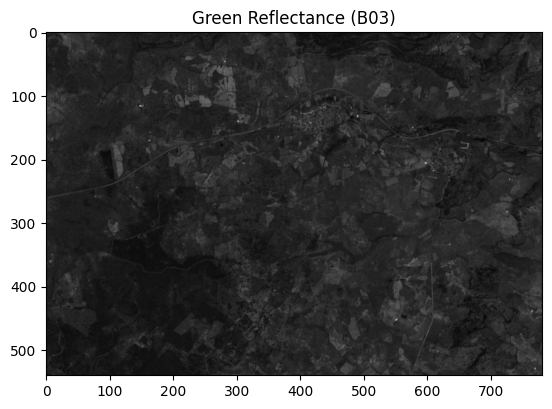

In [133]:
# Cloud mask using SCL
scl = data["SCL"].squeeze()
valid_mask = scl.isin([2, 4, 5, 6, 7, 11])

# Apply mask to bands
red = data["B04"].squeeze().where(valid_mask)
grn = data["B03"].squeeze().where(valid_mask)
blu = data["B02"].squeeze().where(valid_mask)

# Compute
red = red.compute()
grn = grn.compute()
blu = blu.compute()

# Visualize
plt.imshow(grn.values, cmap="gray")
plt.title("Green Reflectance (B03)")